# Restaurant Sales Analysis — Data Mining (Market Basket Analysis)

**Data mining task:** Association rule mining (Apriori algorithm) to find which menu items are frequently bought together, in order to support combo-meal / bundling recommendations.

## 1. Load and inspect the data

In [1]:
import pandas as pd

df = pd.read_csv("restaurant_sales_raw.csv")
print(df.shape)
df.head()

(500, 9)


,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time,Sales Amount
0,1055,David Gutierrez,Ice Cream,Dessert,5,3.97,Online Payment,1/8/2025 22:56,19.85
1,1057,Hannah Brown,Soup,Starter,5,5.12,Credit Card,4/8/2025 3:59,25.60
2,1066,Melissa Duncan,Fries,Starter,2,22.97,Debit Card,7/6/2025 8:10,45.94
3,1084,Eric Nguyen,Pizza,Main,4,22.41,Online Payment,3/24/2025 1:48,89.64
4,1088,Carol Lynch,Ice Cream,Dessert,1,14.82,Cash,4/12/2025 10:21,14.82


In [2]:
df.info()
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        500 non-null    int64  
 1   Customer Name   500 non-null    str    
 2   Food Item       500 non-null    str    
 3   Category        500 non-null    str    
 4   Quantity        500 non-null    int64  
 5   Price           500 non-null    float64
 6   Payment Method  500 non-null    str    
 7   Order Time      500 non-null    str    
 8   Sales Amount    500 non-null    float64
dtypes: float64(2), int64(2), str(5)
memory usage: 35.3 KB

Missing values:
 Order ID          0
Customer Name     0
Food Item         0
Category          0
Quantity          0
Price             0
Payment Method    0
Order Time        0
Sales Amount      0
dtype: int64

Duplicate rows: 0


## 2. Build the transaction basket

Each transaction is one `Order ID`; the items are the distinct `Food Item`s ordered together.

In [3]:
transactions = df.groupby("Order ID")["Food Item"].apply(list).tolist()
print("Total orders (transactions):", len(transactions))
transactions[:5]

Total orders (transactions): 485


[['Ice Cream'], ['Soup'], ['Fries'], ['Pizza'], ['Ice Cream']]

### Data limitation check

Association rule mining only produces meaningful rules when orders contain **multiple** items. We check how many orders actually have more than one distinct item.

In [4]:
multi_item_orders = df.groupby("Order ID")["Food Item"].nunique()
print("Total orders:", len(multi_item_orders))
print("Orders with 2+ distinct items:", (multi_item_orders >= 2).sum())
print("Orders with only 1 item:", (multi_item_orders == 1).sum())

Total orders: 485
Orders with 2+ distinct items: 6
Orders with only 1 item: 479


**Observation:** the vast majority of orders in this dataset contain a single item. Only a handful of orders have 2+ distinct items, so the association rules below are based on a small number of co-occurrences. We proceed with the analysis, but this limitation is noted explicitly here and again in the conclusion — it is a property of the dataset, not a flaw in the method.

## 3. One-hot encode the basket

In [5]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)
basket.head()

,Brownie,Burger,Cake,Fries,Ice Cream,Pasta,Pizza,Salad,Soup
0,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False
4,False,False,False,False,True,False,False,False,False


## 4. Frequent itemsets (Apriori)

`min_support` is set to `1/num_transactions` — the lowest possible threshold — since the dataset has very few multi-item orders and a higher threshold would return zero itemsets of size 2+.

In [6]:
from mlxtend.frequent_patterns import apriori

min_support = 1 / len(transactions)
print("Minimum support used:", round(min_support, 5))

frequent_itemsets = apriori(basket, min_support=min_support, use_colnames=True)
frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)
print("Frequent itemsets found:", len(frequent_itemsets))
frequent_itemsets.sort_values("support", ascending=False).head(10)

Minimum support used: 0.00206
Frequent itemsets found: 25


,support,itemsets,itemset_size
6,0.138144,frozenset({Pizza}),1
0,0.127835,frozenset({Brownie}),1
3,0.123711,frozenset({Fries}),1
7,0.113402,frozenset({Salad}),1
2,0.109278,frozenset({Cake}),1
1,0.105155,frozenset({Burger}),1
4,0.103093,frozenset({Ice Cream}),1
8,0.101031,frozenset({Soup}),1
5,0.098969,frozenset({Pasta}),1
13,0.004124,"frozenset({Burger, Pizza})",2


## 5. Generate association rules

In [7]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.20)
rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]]
rules = rules.sort_values(by="lift", ascending=False)

rules_clean = rules.copy()
rules_clean["antecedents"] = rules_clean["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules_clean["consequents"] = rules_clean["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules_clean = rules_clean.reset_index(drop=True)

print("Total association rules:", len(rules_clean))
rules_clean

Total association rules: 12


,antecedents,consequents,support,confidence,lift
0,"Brownie, Pizza",Burger,0.002062,1.0,9.509804
1,"Fries, Pizza",Burger,0.002062,1.0,9.509804
2,"Fries, Salad",Cake,0.002062,1.0,9.150943
3,"Pizza, Salad",Cake,0.002062,1.0,9.150943
4,"Cake, Pizza",Salad,0.002062,1.0,8.818182
5,"Cake, Fries",Salad,0.002062,1.0,8.818182
6,"Brownie, Burger",Pizza,0.002062,1.0,7.238806
7,"Burger, Fries",Pizza,0.002062,1.0,7.238806
8,"Cake, Salad",Fries,0.002062,0.5,4.041667
9,"Burger, Pizza",Fries,0.002062,0.5,4.041667


In [8]:
rules_clean.to_csv("association_rules.csv", index=False)
print("Saved association_rules.csv")

Saved association_rules.csv


## 6. Visualize the top rules by lift

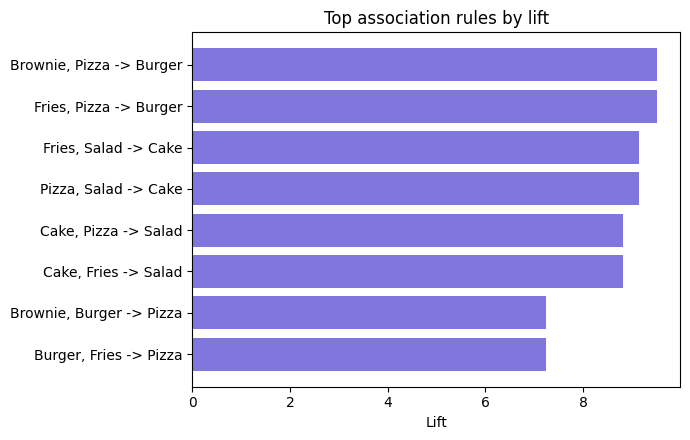

In [9]:
import matplotlib.pyplot as plt

top = rules_clean.head(8).copy()
top["rule"] = top["antecedents"] + " -> " + top["consequents"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top["rule"][::-1], top["lift"][::-1], color="#7F77DD")
ax.set_xlabel("Lift")
ax.set_title("Top association rules by lift")
plt.tight_layout()
plt.savefig("chart4_assoc_rules.png", dpi=150)
plt.show()

## 7. Interpretation

- **Support** — how often the itemset appears across all orders.
- **Confidence** — given the antecedent was ordered, how often the consequent was also ordered.
- **Lift** — how much more likely the consequent is, given the antecedent, versus chance. Lift > 1 indicates a positive association.

The rules with the highest lift (e.g. Brownie + Pizza -> Burger) suggest menu items that tend to be ordered together in this dataset. Given the small number of multi-item orders, these should be treated as **early signals** rather than statistically robust patterns — see limitation noted in Section 2.

## 8. Conclusion and future scope

- Market basket analysis identified a small set of item combinations with high lift, which could inform combo-meal recommendations (e.g. bundling Brownie with Pizza and Burger).
- The main limitation is that most orders in this dataset are single-item orders, which sharply limits the statistical strength of any association rules.
- **Future scope:** collect data at the basket level with more multi-item orders (e.g. from POS systems that log full receipts), and re-run this analysis with a higher, more standard `min_support` threshold (e.g. 0.02–0.05) once more multi-item transactions are available. Category-level itemsets (Starter/Main/Dessert combos) could also be explored as a complementary, coarser-grained analysis.